# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

# План работы

## Этап 1. Подготовка среды и библиотек

In [1]:
!pip install -q scikit-learn numpy pandas seaborn phik joblib

In [2]:
# Импорт библиотек
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import phik
import joblib

In [3]:
# Глобальная настройка библиотек
mpl.rcParams['figure.constrained_layout.use'] = True

In [4]:
# Random state
RANDOM_STATE=1703

In [6]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/coffee_churn_dataset.csv', sep=',', decimal='.')
df.head()

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


## Этап 2. Первичный анализ данных

### 1. Опишите данные. Кратко сообщите, что известно о пользователях и их поведении.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   str    
 14  last_drink_size  

In [8]:
df.describe(include='all')

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
count,10450,9505.000000,9850.000000,10062.000000,9867.000000,9619.000000,10156.000000,9506.000000,10053.000000,10192,...,9913.000000,9757.000000,9593.000000,9729.000000,9771,9719.000000,10114,9840.000000,10340,10450.000000
unique,10450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,...,NaN,NaN,NaN,NaN,4,NaN,3,NaN,100,NaN
top,user_00318,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,arabica,...,NaN,NaN,NaN,NaN,spring,NaN,android,NaN,geo_2,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6134,...,NaN,NaN,NaN,NaN,2507,NaN,4611,NaN,1629,NaN
mean,NaN,4.394214,4.025666,0.930686,1063.741207,452.651500,1946.132979,413.004760,0.284446,NaN,...,0.753052,4.206709,4.022460,1.013362,NaN,14.554584,NaN,0.192480,NaN,0.060191
std,NaN,4.858757,2.826144,0.657261,707.713396,258.657571,2370.619590,445.634902,0.158735,NaN,...,0.431258,0.782212,1.207883,1.010342,NaN,15.308869,NaN,0.394268,NaN,0.237852
min,NaN,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559468,0.002162,NaN,...,0.000000,1.415526,-0.897000,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
25%,NaN,1.000000,1.937767,0.445185,552.898663,262.908598,629.680382,136.565833,0.159884,NaN,...,1.000000,3.675543,3.214157,0.000000,NaN,4.000000,NaN,0.000000,NaN,0.000000
50%,NaN,3.000000,3.381094,0.784839,898.643524,406.456818,1300.409757,288.277327,0.264583,NaN,...,1.000000,4.203555,3.990032,1.000000,NaN,10.000000,NaN,0.000000,NaN,0.000000
75%,NaN,6.000000,5.439363,1.262350,1406.332153,590.418070,2481.650495,549.699420,0.387056,NaN,...,1.000000,4.717292,4.845225,2.000000,NaN,20.000000,NaN,0.000000,NaN,0.000000


In [9]:
df['subscription_status'].value_counts()

subscription_status
none       3803
basic      2862
premium    1923
pro         924
Name: count, dtype: int64

In [10]:
df['phone_type'].value_counts()

phone_type
android    4611
ios        4502
web        1001
Name: count, dtype: int64

In [11]:
df['coffee_preference_change'].value_counts()

coffee_preference_change
0.0    7946
1.0    1894
Name: count, dtype: int64

In [12]:
df['seasons'].value_counts()

seasons
spring    2507
autumn    2433
winter    2423
summer    2408
Name: count, dtype: int64

In [13]:
df['churn'].value_counts()

churn
0    9821
1     629
Name: count, dtype: int64

Обзорно можно сделать следующие выводы:
- "идентификатор пользователя" - id пользователя в системе, бесполезен для обучения модели
- "количество дней, прошедших с последнего заказа" - в среднем около 3-4 дней, но ясно есть выбросы у пользователей, которые перестали покупать кофе
- "среднее число заказов в месяц" и "среднее число заказов в неделю" - в среднем один кофе в неделю и 4 кофе в месяц, но есть и постоянные ежедневные покупатели. Признаки коррелируют, возьмем для обучения "среднее число заказов в неделю"
- "средний чек, в рублях" и "медианный чек, в рублях" - медиана в 2 раза меньше среднего, значит есть большое количество выбросов в размерах чека и лучше использовать медиану в обучении модели
- "сумма заказов за последний месяц" и "сумма заказов за последнюю неделю" - в среднем 400 рублей в неделю и 2000 в месяц. Признаки коррелируют, возьмем для обучения "сумма заказов за последнюю неделю"
- "доля заказов со скидкой за последний месяц" - доля варьируется от около нулевой до 0.89. Признак информативный, возьмем для обучения
- "сорт кофе, купленный пользователем в последний раз на момент сбора данных", "предпочитаемый тип обжарки", "предпочитаемый тип молока", "страна происхождения зерна" - категориальные признаки с небольшим количеством значений. Возможна корреляция между любимым кофе покупателя и его заинтересованностью в кофейне, например что-то могут готовить отлично, а что-то не очень качественно
- "отметка о том, пробовал ли пользователь новейшее сезонное меню" - данный признак может указывать на заинтересованность пользователя, возьмем для обучения
- "размер последнего заказа, совершённого на момент сбора данных" - можем предположить, что чем больше объем кофе, тем больше заинтересованность кофе, проанализируем подробнее на этапе выявления корреляций
- "тип подписки пользователя" - пользователь с подпиской явно заинтересован в кофейне больше, чем пользователь без подписки. Что можно сказать и про пользователя с более высоким уровнем подписки
- "сколько раз за неделю пользователь в среднем открывал приложение доставки кофе" - возможно коррелирует с признаком среднее число заказов в неделю", но потенциально может быть полезен в обучении. Проанализируем подробнее на этапе выявления корреляций
- "включены ли у пользователя уведомления" - пользователь с включенными уведомлениями явно больше заинтересован, чем с выключенными
- "средняя оценка последних на момент сбора данных десяти заказов клиента" - пользователь, которого часто что-то не устраивает вероятно уйдет, а в данных минимальный рейтинг около 1, посмотрим на корреляцию этого признака с таргетом чуть позже
- "оценка последнего на момент сбора данных заказа клиента" - пользователь может перестать совершать покупки и после одного неудачного заказа, так что данная оценка может быть информативной
- "сколько раз приложение зависало за последний месяц" - часто зависание приложения, становится раздражающим фактором и легко может привести к оттоку покупателей
- "текущее время года" - стоит оценить корреляцию между временем года и таргетом. Возможно в какой-то период кофейня становится менее привлекательной
- "сколько дней прошло с последнего использования акции или промокода" - активные пользователи акций более вероятно лояльны
- "тип устройства, с которого пользователь чаще всего совершал покупки" - возможна связь с таргетом, если на разных типах устройств приложения отличаются, но может коррелировать с зависаниями приложения
- "менялись ли вкусовые предпочтения пользователя" - изменение вкусовых предпочтений может повлиять на желание покупателя искать новые вкусы вне нашего кафе и повлиять на уход
- "идентификатор региона пользователя" - в данных 100 регионов, лучше всего для кодирования подойдет Target Encoding, но стоит проверить, есть ли заметная корреляция между регионом и таргетом
- "перестал ли пользователь пользоваться сервисом" - таргет, распределение классов не равномерное, доля положительного класса 0.06, важно это учесть при подготовке к обучению модели

### 2. Опишите целевую переменную

Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.

In [14]:
df['churn'].value_counts()

churn
0    9821
1     629
Name: count, dtype: int64

Целевая переменная сильно несбалансирована: доля оттока (churn = 1) составляет ~6% (629 из 10450), а основной класс — ~94%.

Это означает:

- модель может быть смещена в сторону предсказания класса 0
- accuracy неинформативна, нужно использовать метрики типа PR-AUC, ROC-AUC, F1

### 3. Опишите признаки

   - Определите, все ли из них важны.
   - Объясните, какие из них можно удалить (если такие есть). Аргументируйте своё решение.

Краткое описание признаков приведенов пункте 2.1

Из всех признаков на данный момент можно точно удалить `user_id`. Он не несет полезной информации относительно таргета и при этом может вызвать переобучение модели

### 4. Обработайте пропущенные значения.
   - Объясните, как они влияют на данные.
   - Выберите стратегию заполнения пропусков.

Пропуски уменьшают объём доступной информации и могут вносить смещение, если возникают не случайно. Они также искажают распределения признаков и требуют обработки, так как большинство моделей не работает с NaN.


Обработка пропусков требует понимания доменной логики: без этого легко исказить данные и потерять важные сигналы. В идеале такие решения принимаются совместно с экспертом предметной области или дата-инженером, который может объяснить природу пропусков (случайные они или информативные).

В данном задании есть лишь общее указание на наличие пропусков, поэтому будем использовать наиболее универсальные и безопасные подходы.

In [15]:
# количество пропусков по столбцам
df.isna().sum(), df.isna().sum().sum()

(user_id                       0
 days_since_last_order       945
 order_frequency_month       600
 order_frequency_week        388
 avg_order_value             583
 median_order_value          831
 total_spent_last_month      294
 total_spent_last_week       944
 discount_usage_rate         397
 last_coffee_type            258
 preferred_roast             116
 milk_preference             668
 seasonal_menu_tried         989
 coffee_bean_origin          682
 last_drink_size             504
 subscription_status         938
 app_opens_per_week          896
 notifications_enabled       537
 review_rating_last_10       693
 review_rating_last_1        857
 app_crashes_last_month      721
 seasons                     679
 days_since_last_promo       731
 phone_type                  336
 coffee_preference_change    610
 geo_location                110
 churn                         0
 dtype: int64,
 np.int64(15307))

In [16]:
#Количество и доля пропусков в данных
df.isna().any(axis=1).sum(), df.isna().any(axis=1).sum() / len(df)

(np.int64(8171), np.float64(0.7819138755980861))

Пропусков большое количество. В ~78% строк есть явный пропуск хотя бы в одном столбце. Всего явных пропусков ~15 тысяч

Стратегия заполнения пропусков:
- Категориальные признаки - введем категорию `unknown`, чтобы сохранить информацию о неизвестных значениях
- Булевы значения - пропуски считаем за отсутствие признака и заполняем нулями
- Остальные столбцы (числовые) - заполнение медианой, устойчивой к выбросам

### 5. Проанализируйте признаки.

   - Выясните, есть ли в данных признаки, которые можно кодировать. Объясните, почему именно их нужно кодировать.
   - Проанализируйте признаки на предмет того, можно ли использовать некоторые из них для генерации новых  признаков. Укажите возможные стратегии.
   - Определите, есть ли в данных признаки, которые можно удалить.

In [17]:
# Список категориальных признаков
cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.difference(['user_id'])
cat_cols

Index(['coffee_bean_origin', 'geo_location', 'last_coffee_type',
       'last_drink_size', 'milk_preference', 'phone_type', 'preferred_roast',
       'seasons', 'subscription_status'],
      dtype='str')

In [18]:
# Количество уникальных значений в категориальных признаках
df[cat_cols].nunique()

coffee_bean_origin       6
geo_location           100
last_coffee_type         3
last_drink_size          3
milk_preference          6
phone_type               3
preferred_roast          3
seasons                  4
subscription_status      4
dtype: int64

Категориальные данные представленные в данных можно и нужно кодировать, потому что модель логистической регрессии работает только с числами. Для кодирования `geo_location` лучше всего подойдет `TargetEncoder`, для остальных `OneHotEncoder`

In [19]:
# Сохраняем имена столбцов для применения в ColumnTransformer
ohe_cols = cat_cols.difference(['geo_location'])
te_cols = pd.Series(['geo_location'])

На данный момент нельзя сказать, что какие-то признаки можно удалить. Признак `user_id` был удален ранее

### 6. Проанализируйте выбросы.

   - Определите, как они влияют на данные.
   - Выберите способ, которым их можно обработать.

Проанализируем выбросы в числовых столбцах

In [20]:
num_cols = df.select_dtypes(include=['number']).columns.difference(['churn'])

Для начала посмотрим на наличие отрицательных значений в столбцах. Если такие есть, то они не соответствуют доменной логике:

In [21]:
neg_counts = (df[num_cols] < 0).sum()
neg_counts[neg_counts > 0], neg_counts.sum()

(avg_order_value             2
 median_order_value          2
 order_frequency_week       83
 review_rating_last_1        6
 total_spent_last_month      2
 total_spent_last_week     171
 dtype: int64,
 np.int64(266))

Таких значений всего 266. Можем удалить строки с такими значениями из данных. Сделаем это сразу:

In [22]:
# Удаление строк в которых есть хотя бы одно отрицательное значение числового признака
# Пропуски игнорируются
print('Размер до удаления:', len(df))
df = df[(df[num_cols].ge(0) | df[num_cols].isna()).all(axis=1)]
print('Размер после удаления:', len(df))

Размер до удаления: 10450
Размер после удаления: 10262


Далее построим scatter plot и box plot для визуального анализа разброса признаков. При этом отбросим булевы признаки:

In [23]:
# Функция для построения графиков histplot + boxplot по данным
def graphs_for_allocation(df):
    fig, axes = plt.subplots(
        len(df.columns),
        2,
        figsize=(10,  len(df.columns) * 2)
    )

    for i, col in enumerate(df.columns):
        sns.histplot(
            data=df,
            x=col,
            ax=axes[i][0],
        )

        sns.boxplot(
            data=df,
            x=col,
            ax=axes[i][1],
        )

    fig.set_constrained_layout_pads(h_pad=0.2, hspace=0.2, wspace=0.1)
    plt.show()

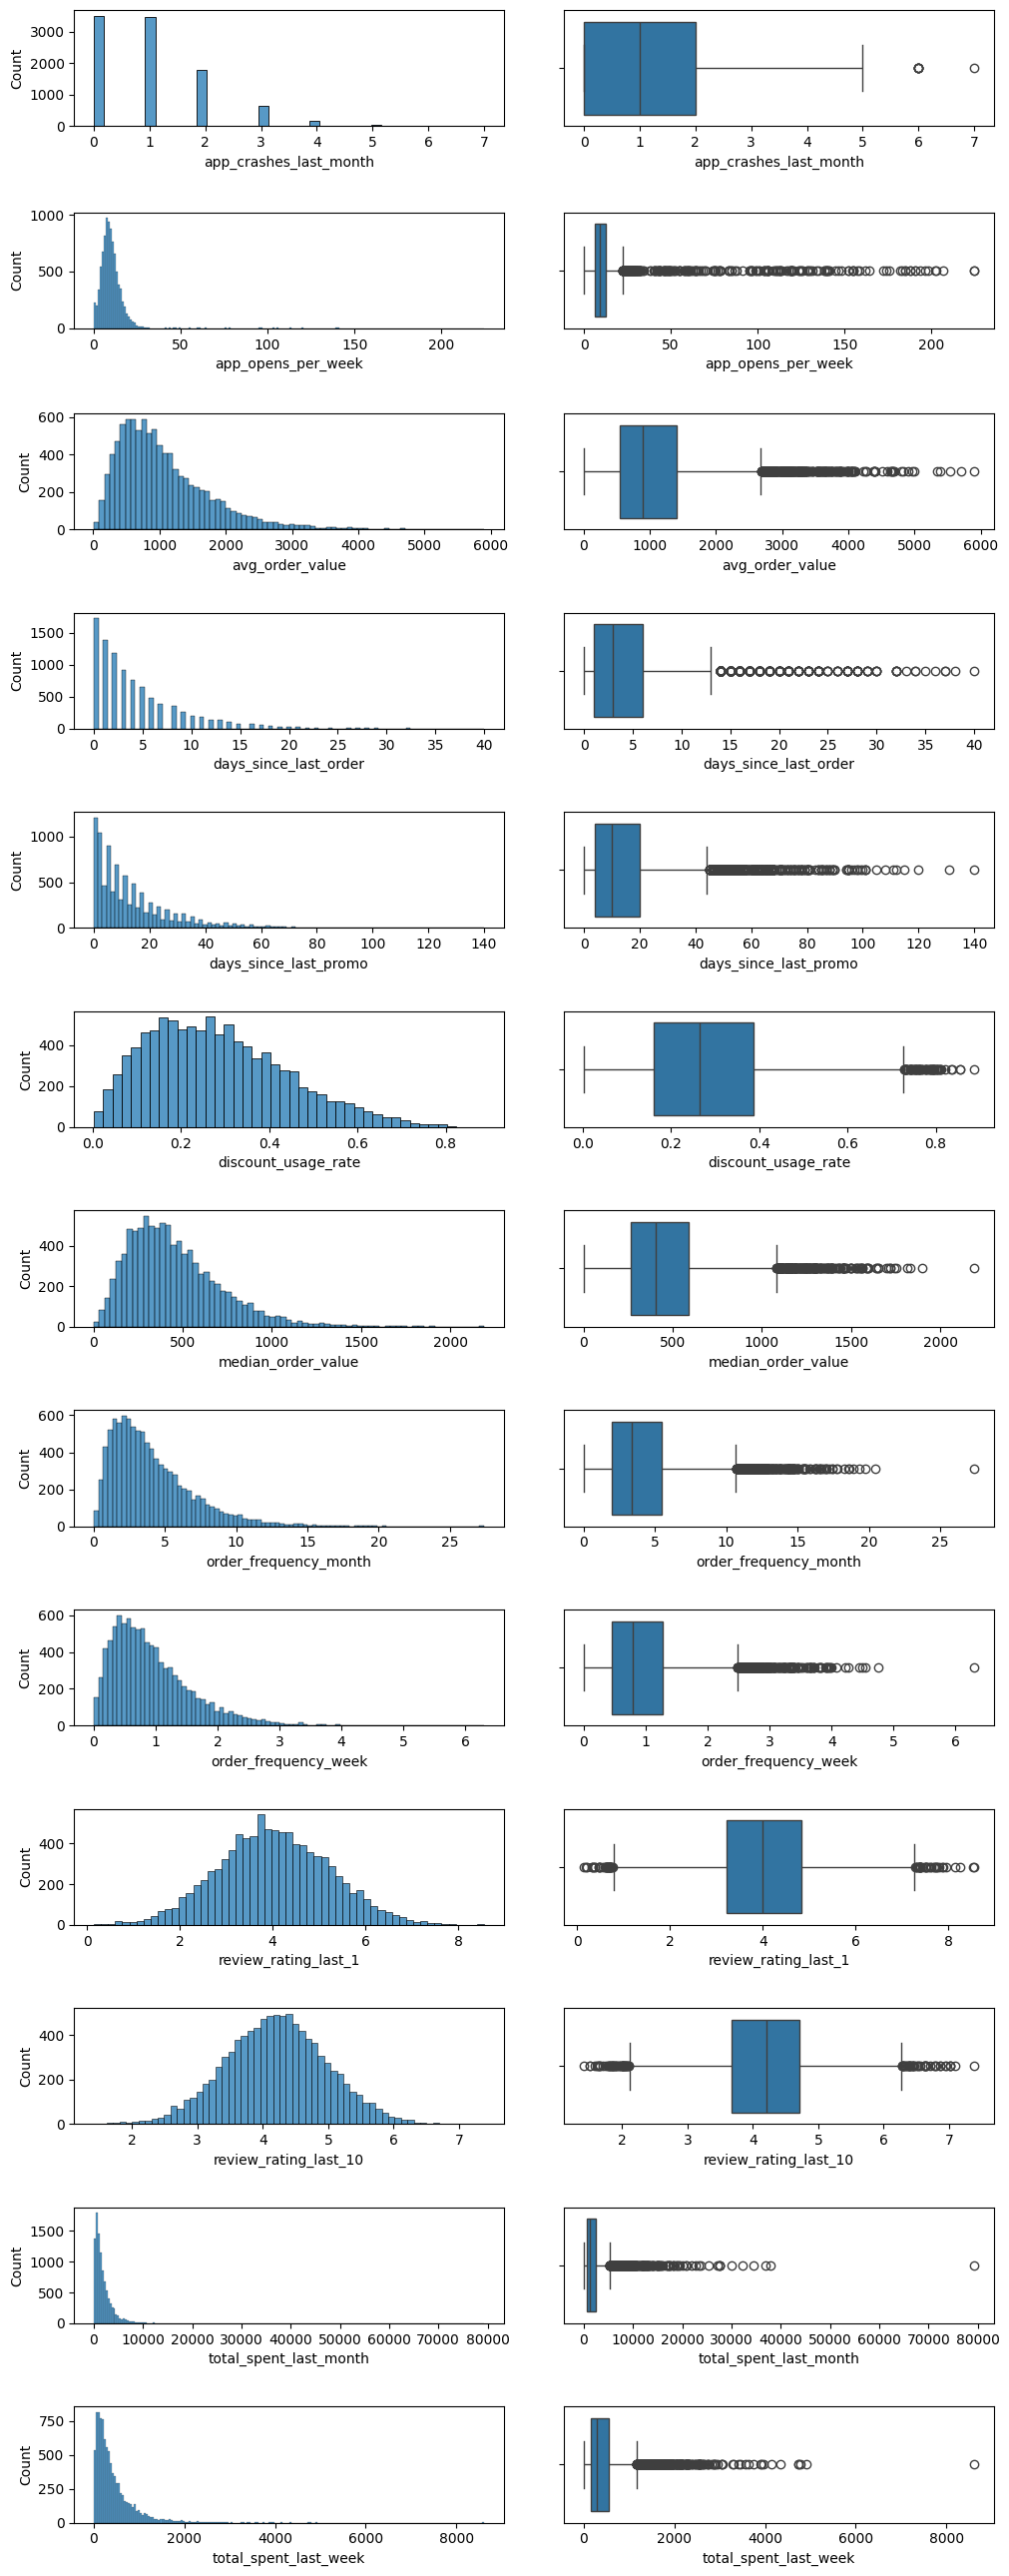

In [24]:
bool_cols = pd.Series([
    'seasonal_menu_tried',
    'notifications_enabled',
    'coffee_preference_change',
])
num_cols = num_cols.difference(bool_cols)
graphs_for_allocation(df[num_cols])

Выбросы разной силы наблюдаются на всех графиках выведенных выше. Посмотрим на количество значений в характеристиках больше 99 перцентиля

In [25]:
# Посчитаем в столбцах `num_cols количество значений больше 99 перцентиля
(df[num_cols] > df[num_cols].quantile(.99)).sum()

app_crashes_last_month     31
app_opens_per_week         94
avg_order_value            97
days_since_last_order      82
days_since_last_promo      91
discount_usage_rate        99
median_order_value         93
order_frequency_month      97
order_frequency_week       99
review_rating_last_1       95
review_rating_last_10      96
total_spent_last_month    100
total_spent_last_week      94
dtype: int64

In [26]:
# Всего строк со значением в столбцах `num_cols` количество значений больше 99 перцентиля
(df[num_cols] > df[num_cols].quantile(.99)).any(axis=1).sum(), len(df)

(np.int64(893), 10262)

В числовых признаках наблюдаются выбросы: около 10% строк содержат значения выше 99-го перцентиля хотя бы в одном признаке.

Удаление такого объёма данных может привести к потере важной информации и ухудшению качества модели.

Вероятно, часть выбросов отражает реальное поведение пользователей (например, высокая частота заказов или крупные траты), а не ошибки в данных.

Поэтому на данном этапе выбросы не удаляются; вместо этого можно рассмотреть методы их обработки. Применим логарифмирование для столбцов `app_opens_per_week`, `avg_order_value`, `days_since_last_order`, `days_since_last_promo`, `median_order_value`, `order_frequency_month`, `total_spent_last_month`, `total_spent_last_week`

In [27]:
cols_to_log = pd.Series([
    'app_opens_per_week',
    'avg_order_value',
    'days_since_last_order',
    'days_since_last_promo',
    'median_order_value',
    'order_frequency_month',
    'total_spent_last_month',
    'total_spent_last_week'
])

### 7. Посчитайте корреляции между признаками

Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.

In [28]:
# Получение phik матрицы. `user_id` убираем из вычислений, так как решили ранее, что его удаляем
cols_to_check = df.columns.difference(['user_id'])
df_phik = df[cols_to_check].phik_matrix(interval_cols=num_cols)

In [29]:
# Функция для построения тепловой карты
def heatmap(df):
    plt.figure(figsize=(20, 15))

    sns.heatmap(
        df,
        cmap="coolwarm",
        vmin=0, vmax=1,
        annot=True, fmt=".2f",
        linewidths=0.5,
        square=True,
        cbar_kws={"shrink": 0.8}
    )

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.title("Phik Correlation Matrix", fontsize=16)
    plt.show()

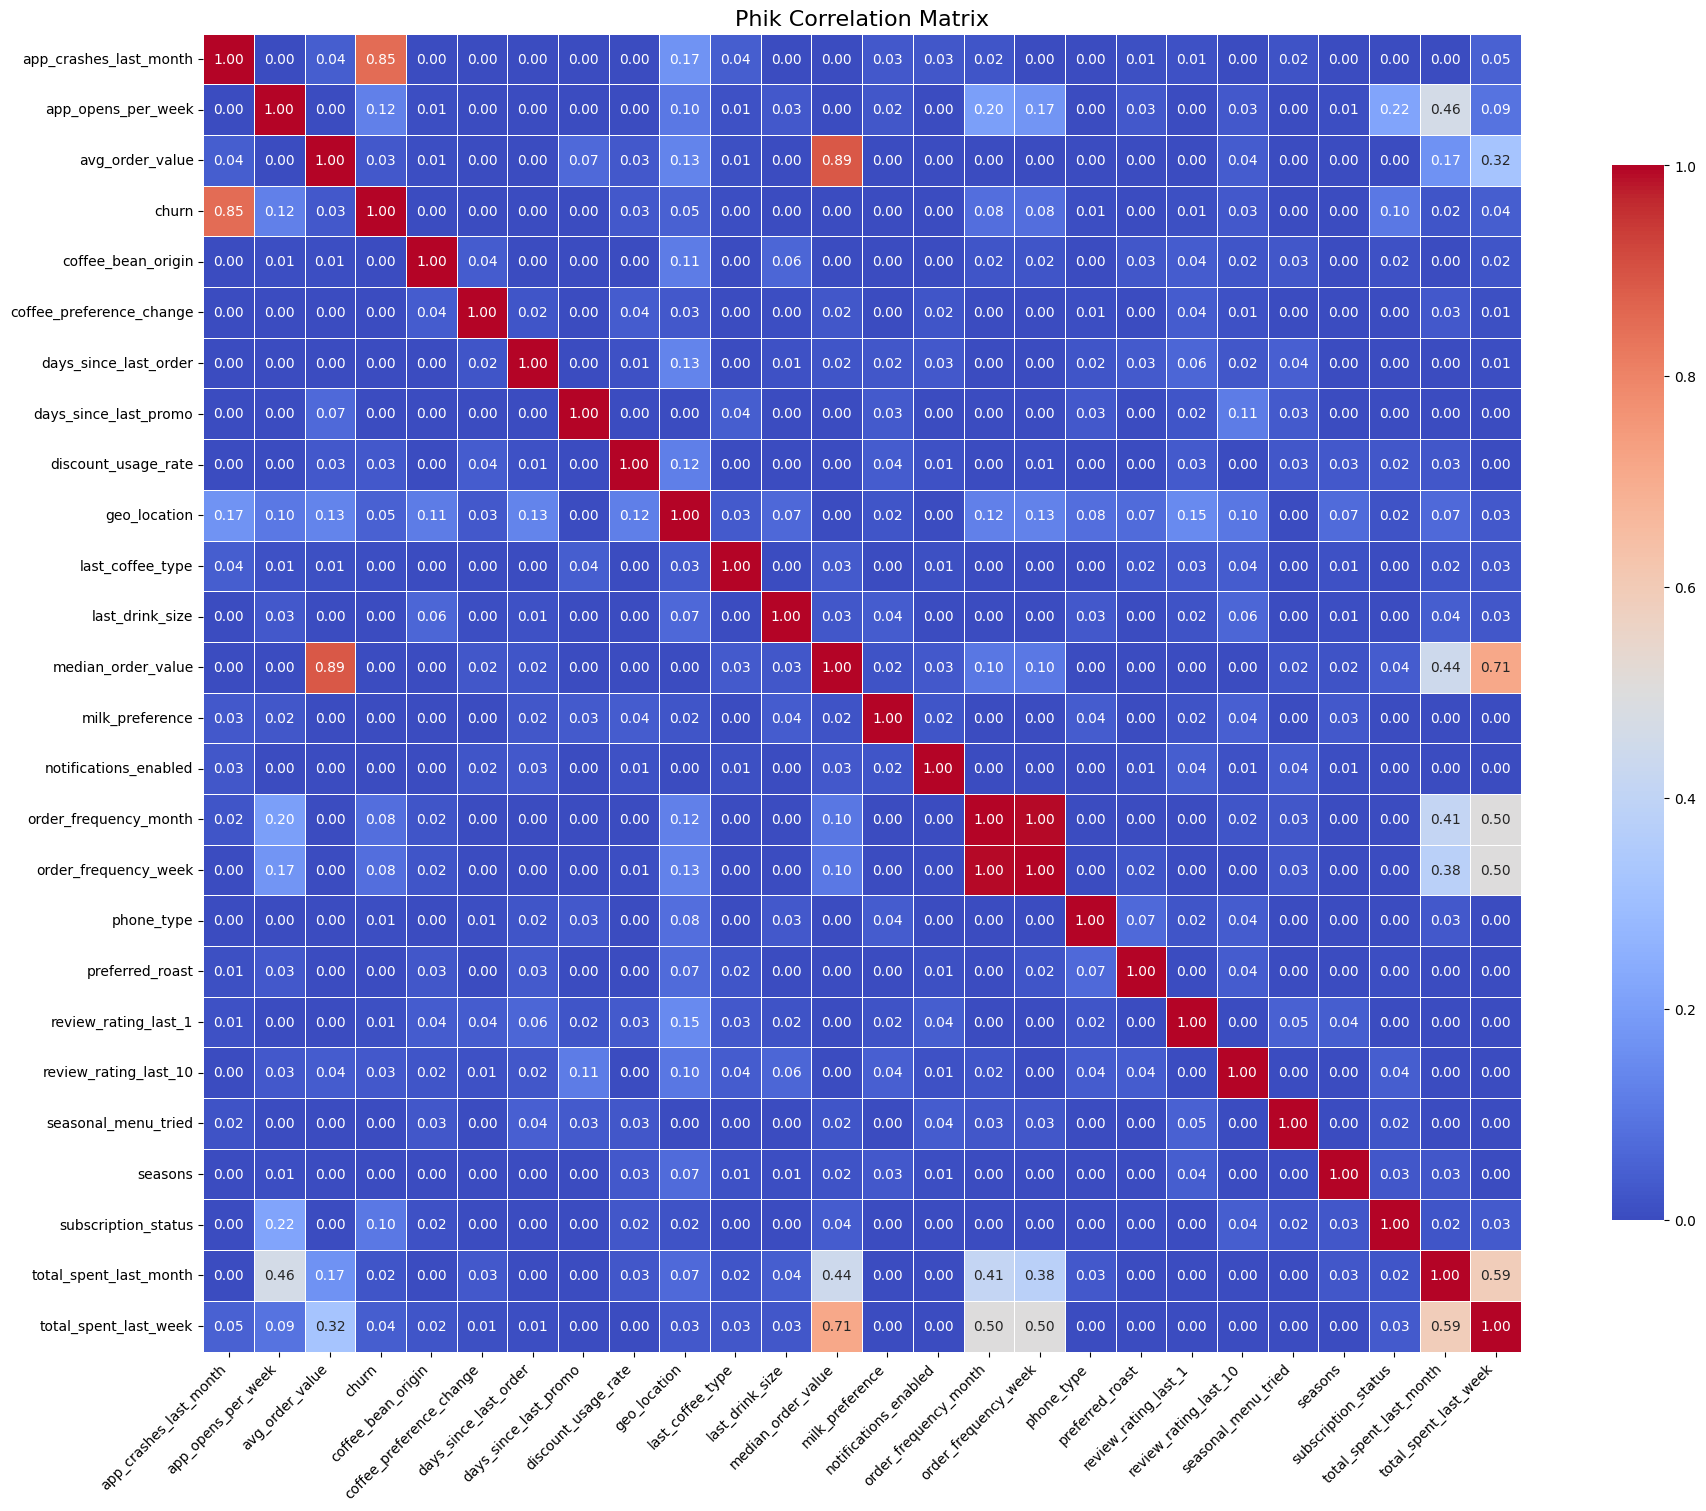

In [30]:
# Построение тепловой карты матрицы корреляций
heatmap(df_phik)

In [31]:
# Функция для получения пар признаков со значением их корреляции
def phik_to_pairs(df_phik):
    s = df_phik.stack()
    s = s[s.index.get_level_values(0) != s.index.get_level_values(1)]
    s = s[s.index.get_level_values(0) < s.index.get_level_values(1)]
    s = s.sort_values(ascending=False)
    return s

In [32]:
# В дополнение к тепловой карте выведем пары с самым большим значением корреляции
phik_to_pairs(df_phik).head(20)

order_frequency_month   order_frequency_week      0.995686
avg_order_value         median_order_value        0.890199
app_crashes_last_month  churn                     0.850702
median_order_value      total_spent_last_week     0.713652
total_spent_last_month  total_spent_last_week     0.591673
order_frequency_week    total_spent_last_week     0.503589
order_frequency_month   total_spent_last_week     0.500547
app_opens_per_week      total_spent_last_month    0.462529
median_order_value      total_spent_last_month    0.441803
order_frequency_month   total_spent_last_month    0.410285
order_frequency_week    total_spent_last_month    0.381014
avg_order_value         total_spent_last_week     0.322660
app_opens_per_week      subscription_status       0.215206
                        order_frequency_month     0.201401
                        order_frequency_week      0.174796
app_crashes_last_month  geo_location              0.171795
avg_order_value         total_spent_last_month    0.1663

**Признаки, которые можно убрать, на основании их корреляции с другими:**
- total_spent_last_month и total_spent_last_week коррелируют с множеством других признаков, но при этом крайне слабо коррелируют с таргетом. Оба **total_spent_last_month и total_spent_last_week** нужно удалить
- order_frequency_month и order_frequency_week очень сильно коррелируют между собой (coef~=.99) - нужно удалить один из признаков. **Удалим order_frequency_week**, так как этот признак хуже коррелирует с таргетом
- avg_order_value и median_order_value очень сильно коррелируют между собой (coef~=.89) - нужно удалить один из признаков. **Удалим median_order_value**, так как этот признак хуже коррелирует с таргетом

In [33]:
# Сохраним все столбцы, которые будут игнорироваться. Удалять из датафрейма их не будем, но они будут проигнорированы при обучении модели
cols_to_ignore = ['user_id', 'total_spent_last_month', 'total_spent_last_week', 'order_frequency_week', 'median_order_value']

Посмотрим повторно на матрицу корреляций без этих признаков:

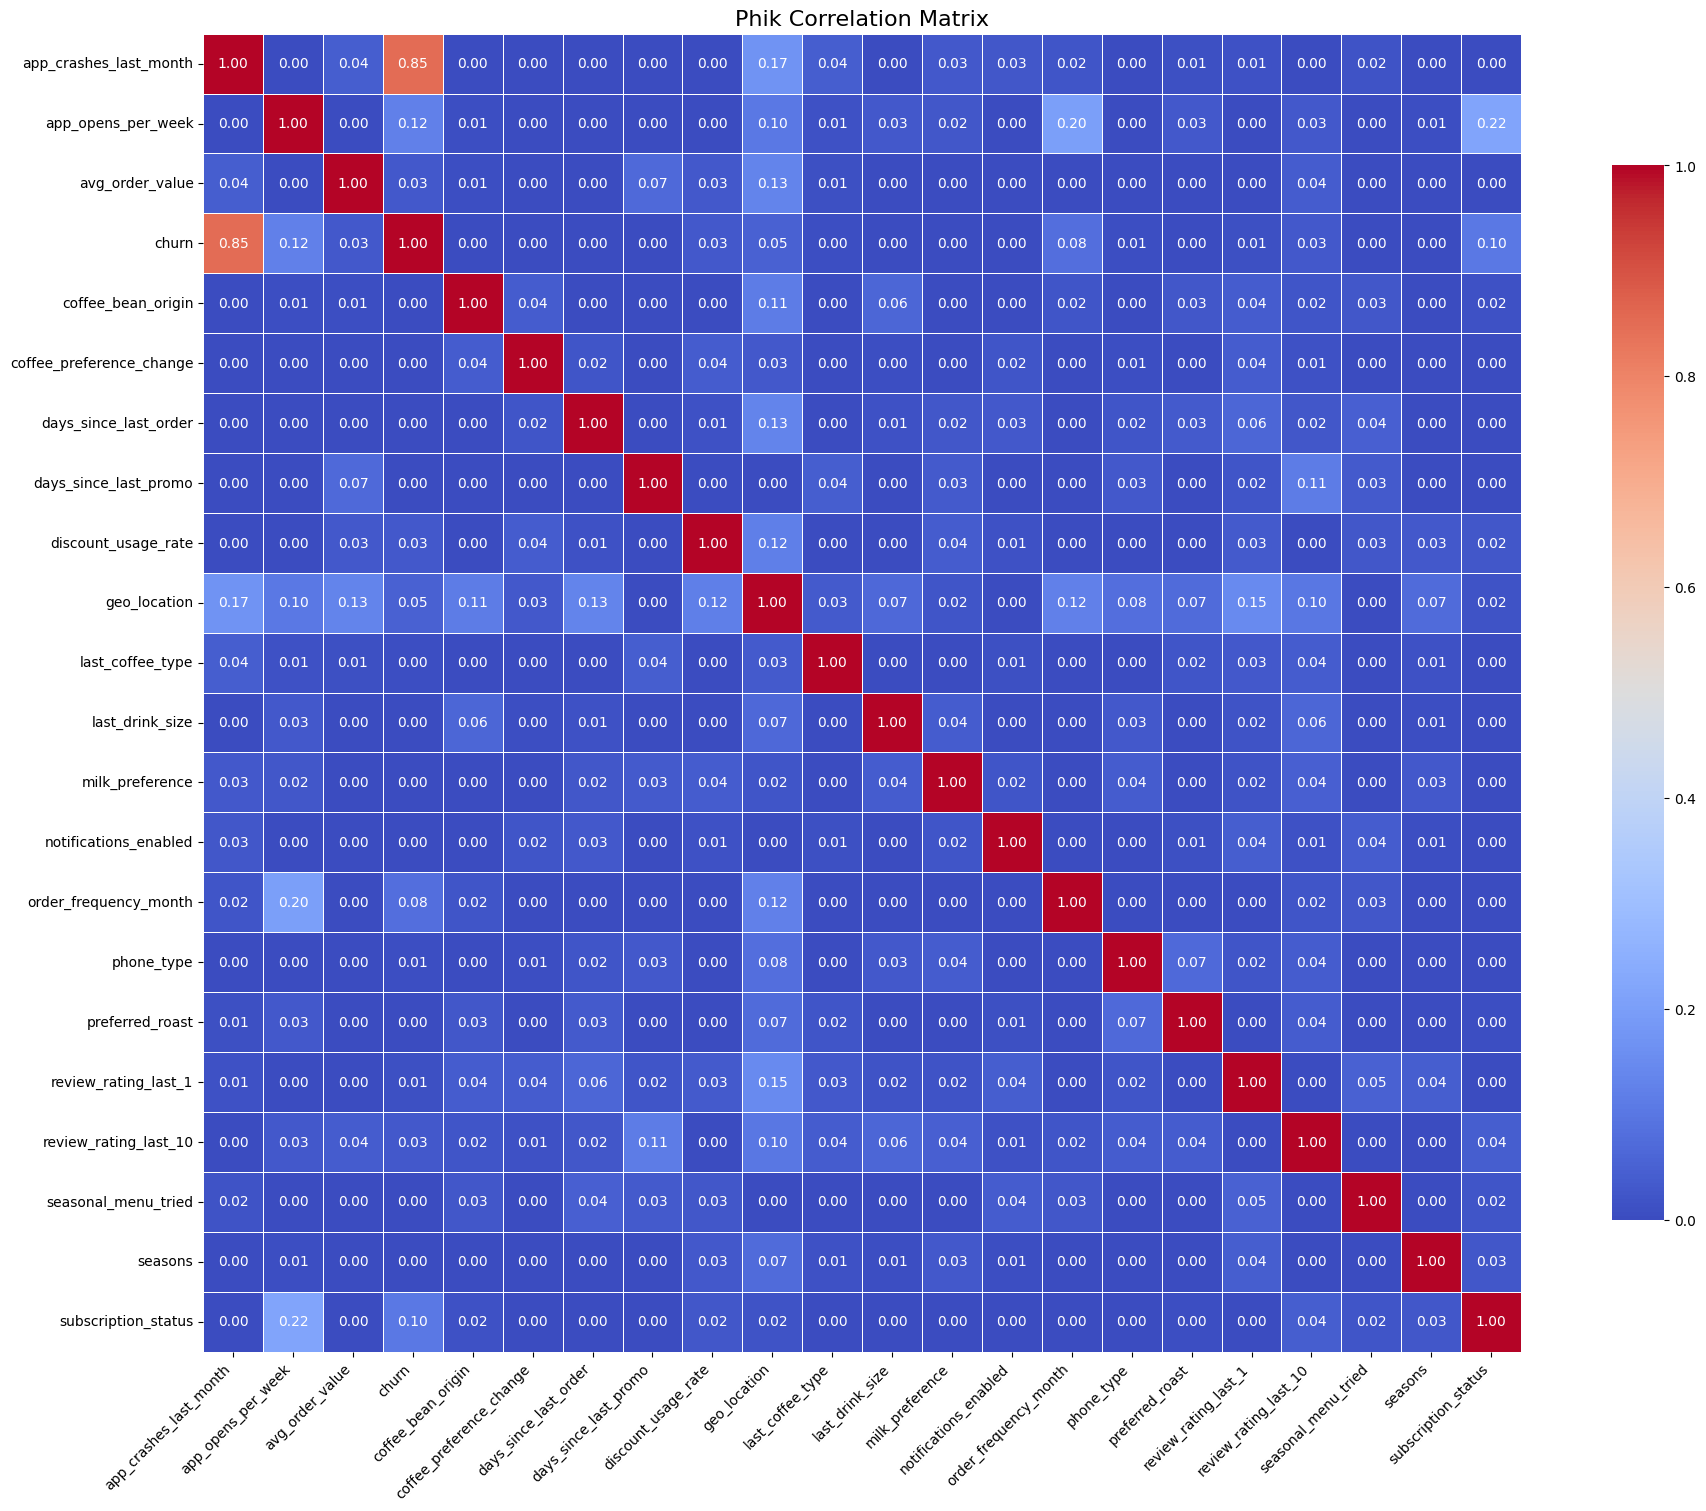

In [34]:
cols_to_check = df.columns.difference(cols_to_ignore)
df_phik = df[cols_to_check].phik_matrix(interval_cols=num_cols)
heatmap(df_phik)

Больше сильно коррелирующих признаков не выявлено

Составим окончательный список столбцов для дальнейшей обработки:

### 8. Напишите выводы по результатам исследовательского анализа данных.

В ходе первичного анализа были изучены структура данных, распределение признаков и их потенциальная значимость для задачи прогнозирования оттока пользователей.

Датасет содержит как количественные, так и категориальные признаки, отражающие поведение пользователей, их предпочтения и взаимодействие с сервисом. Целевая переменная характеризуется выраженным дисбалансом классов: доля оттока составляет около 6%, что требует использования устойчивых к дисбалансу метрик качества (например, PR-AUC, ROC-AUC, F1) на последующих этапах моделирования.

Анализ пропущенных значений показал, что значительная часть данных содержит пропуски. Для их обработки выбраны универсальные стратегии: заполнение категориальных признаков значением unknown, числовых — медианой, булевых — нулями. Такой подход позволяет сохранить объём данных и минимизировать искажения распределений.

В процессе анализа признаков были выявлены избыточные и высоко коррелирующие переменные. В частности, удалены идентификатор пользователя (user_id), а также признаки, дублирующие друг друга по смыслу или имеющие высокую взаимную корреляцию. Это позволяет снизить риск мультиколлинеарности и повысить устойчивость модели.

Выбросы присутствуют во многих числовых признаках, однако их природа, вероятно, связана с особенностями поведения пользователей, а не с ошибками данных. В связи с этим было принято решение не удалять такие наблюдения, а учитывать их с помощью преобразований логарифмирования.

Категориальные признаки требуют кодирования для использования в модели: для признаков с большим количеством уникальных значений целесообразно применение Target Encoding, для остальных — One-Hot Encoding.

Также были определены направления для генерации новых признаков, способных повысить качество модели, включая показатели частоты и давности заказов, конверсии, динамики поведения и изменения пользовательского опыта.

В результате проведённого анализа данные признаны пригодными для дальнейшего моделирования после выполнения этапа предобработки.

## Этап 3. Предобработка данных

### 1. Разделите данные в пропорции 80 к 20.

In [35]:
# Разделение данных
from sklearn.model_selection import train_test_split

X = df.drop(columns='churn')
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

### 2. Предобработайте данные.

In [36]:
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer


# Пайплайн предобработки данных:
# - обрабатывает пропуски
# - обрабатывает выбросы через логарифмирование части числовых признаков
# - кодирует категориальные признаки
# - масштабирует числовые признаки
def get_preprocessor(cols_to_log, ohe_cols, te_cols, num_cols, bool_cols, cols_to_ignore):
    # Игнорирование части признаков, переданных в функцию
    bool_cols = bool_cols[~bool_cols.isin(cols_to_ignore)]

    num_cols = num_cols[~num_cols.isin(cols_to_ignore)]
    cols_to_log = cols_to_log[~cols_to_log.isin(cols_to_ignore)]

    te_cols = te_cols[~te_cols.isin(cols_to_ignore)]
    ohe_cols = ohe_cols[~ohe_cols.isin(cols_to_ignore)]

    return ColumnTransformer([
        # Пайплайн для категориальных признаков с небольшим числом уникальных значений
        ('ohe', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
            ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
        ]), ohe_cols),

        # Пайплайн для категориальных признаков с большим числом уникальных значений
        ('te', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
            ('encoder', TargetEncoder(random_state=RANDOM_STATE))
        ]), te_cols),

        # Пайплайн для числовых признаков с выбросами:
        # заполняем пропуски, логарифмируем и масштабируем
        ('num_log', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('log', FunctionTransformer(np.log1p, validate=False, feature_names_out='one-to-one')),
            ('scaler', StandardScaler())
        ]), cols_to_log),

        # Пайплайн для остальных числовых признаков:
        # заполняем пропуски и масштабируем
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), [col for col in num_cols if col not in cols_to_log.values]),

        # Пайплайн для бинарных признаков
        ('bool', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value=0))
        ]), bool_cols),

    ], remainder='drop')

## Этап 4. Обучение модели

1. Обучите базовую версию модели.
   - Используйте для этого простые статистические модели.

   - Используйте кросс-валидацию для обучения модели.

2. Посчитайте метрики, поставленные в задаче. Опираясь на них, сделайте вывод о качестве модели.

In [37]:
# Базовая модель до создания новых признаков и изменения гиперпараметров
from sklearn.linear_model import LogisticRegression

model_base = make_pipeline(get_preprocessor(cols_to_log, ohe_cols, te_cols, num_cols, bool_cols, cols_to_ignore), LogisticRegression())

In [38]:
# Функция для кросс валидации модели и вывода требуемых результатов
from sklearn.model_selection import cross_validate

def cross_validate_with_info(*, model, X, y):
    cv_result = cross_validate(
        model,
        X,
        y,
        scoring='average_precision',
        cv=5,
        n_jobs=-1
    )

    print('PR-AUC:', cv_result['test_score'].mean())
    print('Доля положительного класса:', y_test.mean())
    print('Разброс метрики: ', cv_result['test_score'].std())

In [39]:
# Вызов кастомной функции кросс валидации на базовой моделе
cross_validate_with_info(
    model=model_base,
    X=X_train,
    y=y_train,
)

PR-AUC: 0.682532655382659
Доля положительного класса: 0.06039941548952752
Разброс метрики:  0.05072185414044231


Модель значительно превосходит случайную: PR-AUC ~0.61 при базовом уровне ~0.057 (доля положительного класса).
Это означает, что модель хорошо ранжирует положительный класс даже при сильном дисбалансе.

При этом разброс между фолдами (~0.52–0.7) указывает на некоторую нестабильность, поэтому есть потенциал для улучшения.

## Этап 5. Создание новых признаков

### 1. Добавьте новые признаки, которые могут улучшить качество модели.

Ранее обсуждалось новых признаков, сгенерируем комбинации тех из них, которые показали корреляцию с таргетом:

In [40]:
# Доменные признаки по стратегиям из п. 5 (R/F, конверсия, неделя/месяц, рейтинг, вовлечённость)
# Функция для пайплайна
def add_features(X):
    _DAYS_PER_MONTH = 30.5
    _WEEKS_PER_MONTH = _DAYS_PER_MONTH / 7

    X = X.copy()

    # Recency–Frequency: высокая месячная частота при малой давности последнего заказа
    X['rf_recency_frequency'] = X['order_frequency_month'] / (X['days_since_last_order'] + 1)

    # Conversion: заказов за неделю на одно открытие приложения за неделю
    X['conversion_orders_per_open'] = X['order_frequency_week'] / (X['app_opens_per_week'] + 1e-6)

    # Week vs month по частоте: ~1 при стабильном поведении
    X['week_month_frequency_ratio'] = (X['order_frequency_week'] * _WEEKS_PER_MONTH) / (X['order_frequency_month'] + 1e-6)

    # Week vs month по тратам (сырые total_* позже исключаются; отношение сохраняет сигнал)
    _month_weekly_spend = X['total_spent_last_month'] / _WEEKS_PER_MONTH
    X['week_month_spend_ratio'] = X['total_spent_last_week'] / np.maximum(_month_weekly_spend, 1e-6)

    # Падение рейтинга: среднее за 10 заказов минус последний ( > 0 — последний хуже среднего)
    X['rating_drop_last_vs_avg'] = X['review_rating_last_10'] - X['review_rating_last_1']

    return X

In [41]:
# Добавляем признаки в список признаков для обработки в ColumnTransformer
num_cols_with_new_features = pd.concat([
    num_cols.to_series(),
    pd.Series(['rf_recency_frequency', 'conversion_orders_per_open', 'week_month_frequency_ratio', 'week_month_spend_ratio', 'rating_drop_last_vs_avg'
    ])
])

cols_to_log_with_new_features = pd.concat([
    cols_to_log,
    pd.Series(['rf_recency_frequency', 'conversion_orders_per_open', 'week_month_frequency_ratio', 'week_month_spend_ratio'
    ])
])

### 2. Обновите пайплайн для работы с новыми признаками

+ Проведите повторную кросс-валидацию, сравните результаты моделей с новыми признаками и без них.

In [42]:
# Инициализация пайплайна для модели с новыми признаками
model_more_features = Pipeline([
    ('features', FunctionTransformer(add_features)),
    ('preprocessor', get_preprocessor(
        cols_to_log_with_new_features,
        ohe_cols,
        te_cols,
        num_cols_with_new_features,
        bool_cols,
        cols_to_ignore)
     ),
    ('model', LogisticRegression())
])

In [43]:
# Вызов кастомной функции кросс валидации на моделе со сгенерированными признаками
cross_validate_with_info(
    model=model_more_features,
    X=X_train,
    y=y_train,
)

PR-AUC: 0.6835832454753809
Доля положительного класса: 0.06039941548952752
Разброс метрики:  0.055700015164982596


Генерация новых признаков незначительно увеличила метрику `PR-AUC` попробуем проанализировать коэффициенты модели

### 3. Интерпретируйте коэффициенты модели

Затем на их основании выявите значимые признаки и удалите лишние для модели.

In [44]:
model_more_features.fit(X_train, y_train)
abs(pd.Series(
    model_more_features.named_steps['model'].coef_[0],
    index=model_more_features.named_steps['preprocessor'].get_feature_names_out()
)).sort_values(ascending=False)

num__app_crashes_last_month            2.189238
ohe__subscription_status_pro           0.681195
num_log__app_opens_per_week            0.675220
num_log__conversion_orders_per_open    0.671594
ohe__phone_type_web                    0.513078
ohe__milk_preference_none              0.489478
ohe__last_coffee_type_robusta          0.466324
ohe__phone_type_unknown                0.437967
ohe__last_coffee_type_unknown          0.406160
bool__seasonal_menu_tried              0.379296
ohe__milk_preference_soy               0.336039
ohe__seasons_unknown                   0.327098
num_log__rf_recency_frequency          0.302528
num_log__days_since_last_order         0.298346
ohe__preferred_roast_unknown           0.292041
ohe__phone_type_ios                    0.291475
ohe__subscription_status_premium       0.275987
ohe__milk_preference_skim              0.251669
ohe__milk_preference_whole             0.250858
ohe__preferred_roast_light             0.230318
ohe__last_coffee_type_blend            0

Удалим признаки, коэффициенты при которых меньше 0.1

С низким коэффициентом, достаточным для удаления оказались следующие признаки:
- rating_drop_last_vs_avg,
- review_rating_last_1
- review_rating_last_10
- conversion_orders_per_open
- seasonal_menu_tried
- avg_order_value

Дополнительно вернемся к данным о корреляции признаков с таргетом и удалим те признаки, корреляция которых с таргетом >= 0.01:

In [45]:
df_phik_churn = df_phik['churn'].drop(index=['churn']).sort_values()
df_phik_churn[df_phik_churn <= 0.01].index.to_list()

['last_drink_size',
 'seasonal_menu_tried',
 'preferred_roast',
 'coffee_bean_origin',
 'coffee_preference_change',
 'days_since_last_order',
 'days_since_last_promo',
 'seasons',
 'milk_preference',
 'notifications_enabled',
 'last_coffee_type',
 'phone_type',
 'review_rating_last_1']

### 4. Удаление малоинформативных признаков

 Удалим все выявленные малоинформативные признаки из модели, а также сгенерированные признаки, к ним вернемся позже:

In [46]:
# Общий список столбцов для удаления
cols_to_ignore = pd.concat([
    pd.Series(cols_to_ignore), # Ранее проигнорированные признаки
    pd.Series([ # Признаки, которые получили низкий коэффициент в моделе
        'rating_drop_last_vs_avg',
        'review_rating_last_1',
        'review_rating_last_10',
        'conversion_orders_per_open',
        'seasonal_menu_tried',
        'avg_order_value',
    ]),
    df_phik_churn[df_phik_churn <= 0.01].index.to_series(), # Признаки с низкой корреляцией с таргетом
    pd.Series([ # Сгенерированные признаки
        'rf_recency_frequency',
        'conversion_orders_per_open',
        'week_month_frequency_ratio',
        'week_month_spend_ratio',
        'rating_drop_last_vs_avg'
    ])
]).drop_duplicates()

Теперь обучим и проверим модель с уменьшенным количеством признаков:

In [47]:
model_light = Pipeline([
    ('preprocessor', get_preprocessor(cols_to_log, ohe_cols, te_cols, num_cols, bool_cols, cols_to_ignore)),
    ('model', LogisticRegression())
])

cross_validate_with_info(
    model=model_light,
    X=X_train,
    y=y_train,
)

PR-AUC: 0.6905487302240301
Доля положительного класса: 0.06039941548952752
Разброс метрики:  0.05567625452082502


Метрика PR-AUC выросла с ~0.68 до ~0.69 - это незначительное, но приятное улучшение, особенно если учитывать, что добились мы его путем уменьшения количества используемых признаков

Проанализируем коэффициенты получившейся модели:

In [48]:
model_light.fit(X_train, y_train)
abs(pd.Series(
    model_light.named_steps['model'].coef_[0],
    index=model_light.named_steps['preprocessor'].get_feature_names_out()
)).sort_values(ascending=False)

num__app_crashes_last_month         2.116959
ohe__subscription_status_pro        0.710548
num_log__app_opens_per_week         0.606526
num_log__order_frequency_month      0.360137
ohe__subscription_status_premium    0.299247
te__geo_location                    0.213212
ohe__subscription_status_unknown    0.129384
ohe__subscription_status_none       0.042589
num__discount_usage_rate            0.001091
dtype: float64

 В облегченной моделе осталось всего 11 признаков. И один из них `discount_usage_rate` почти занулился. Удалим его в следующей итерации модели

In [49]:
cols_to_ignore = pd.concat([cols_to_ignore, pd.Series(['discount_usage_rate'])])

### 4. Добавление новых информативных признаков

В первой попытке добавления новых признаков применение слабо коррелирующих с таргетом признаков не дало результата. Сейчас в данных остались только признаки с заметной корреляцией с таргетом. Выведем их и попробуем повторно сгенерировать новые признаки

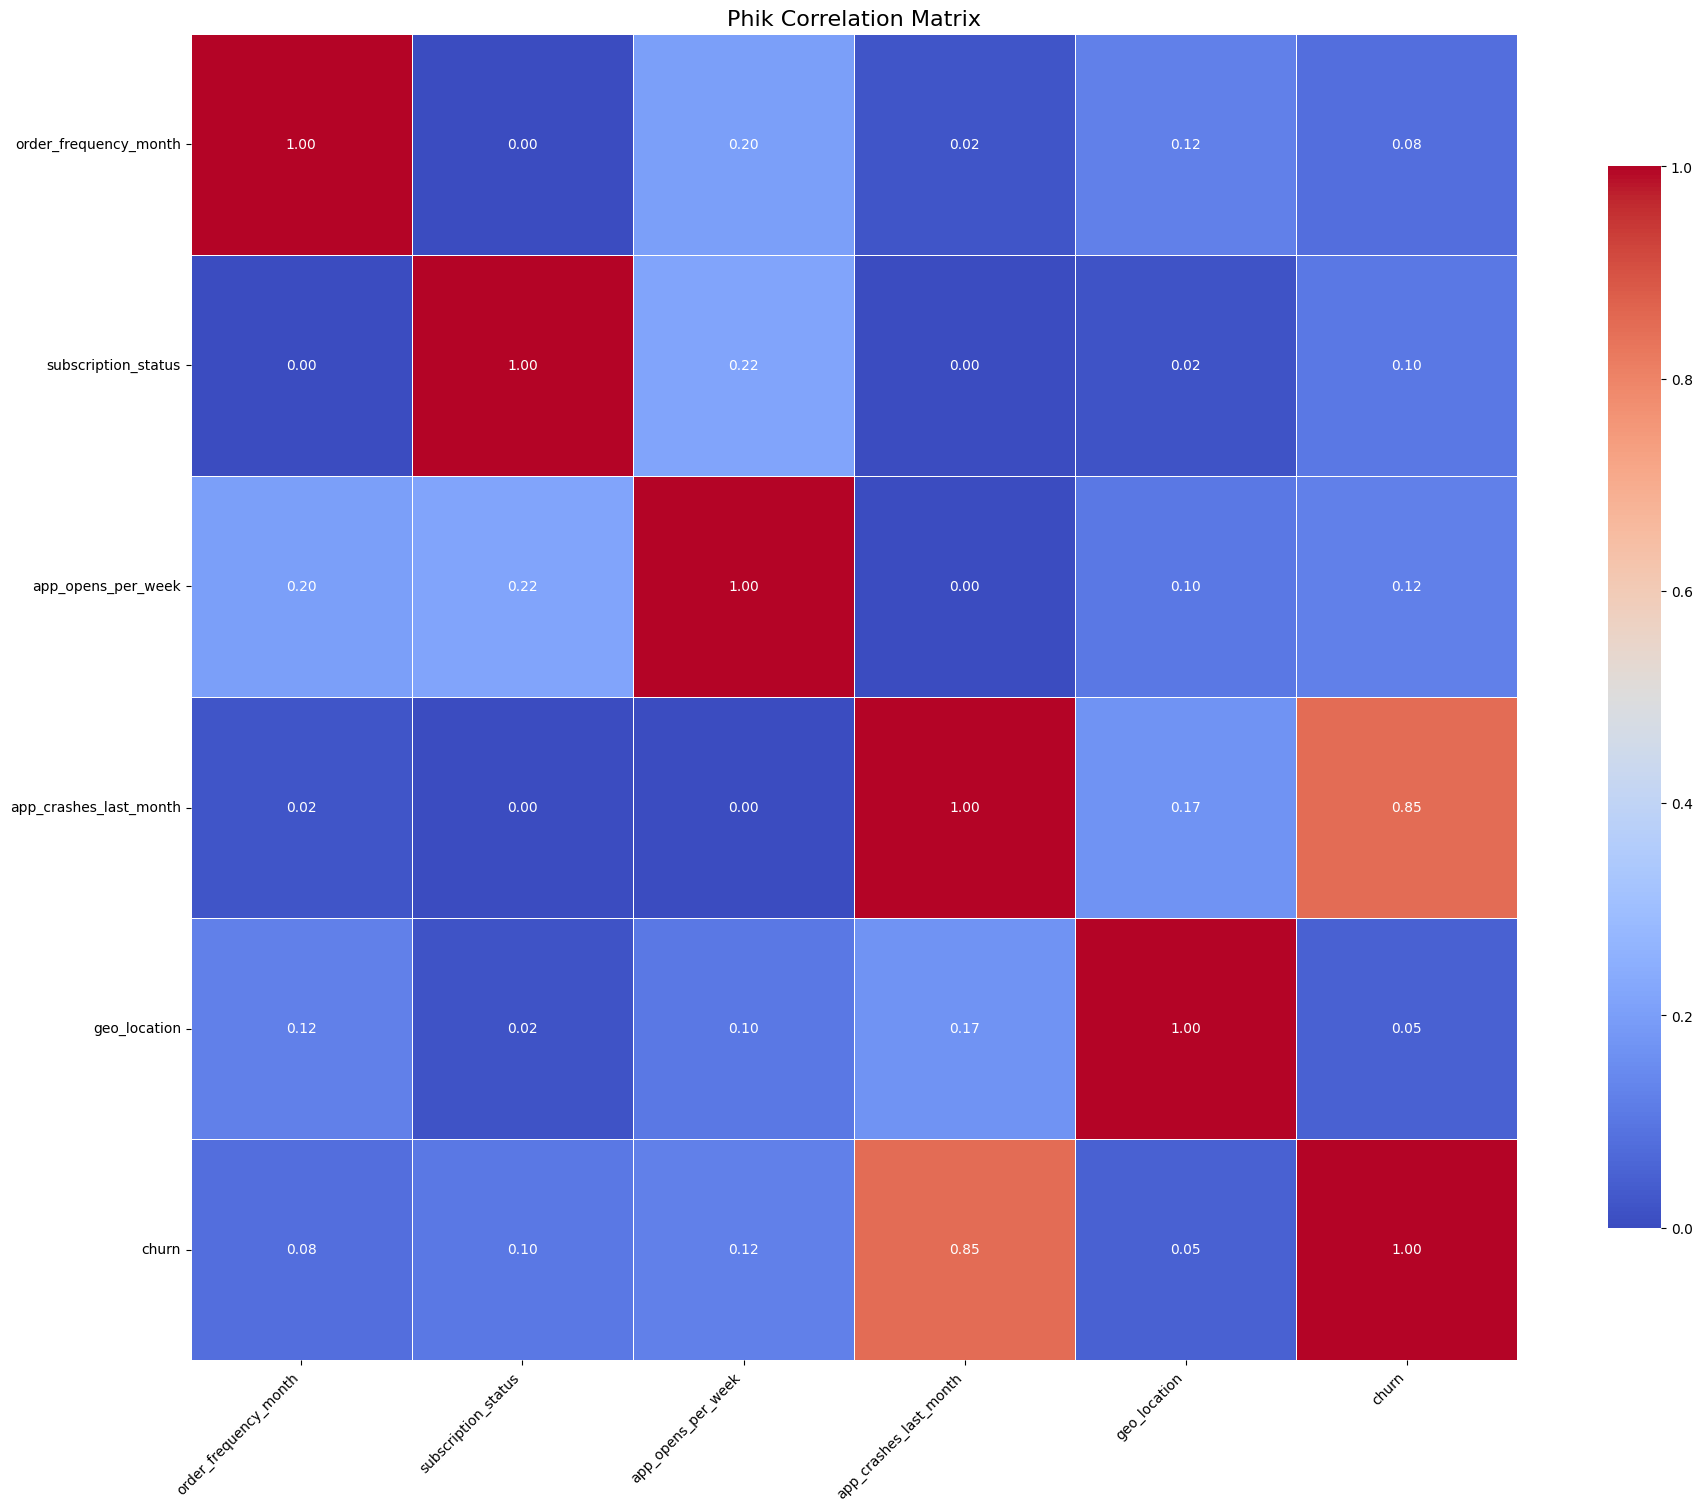

In [50]:
heatmap(
    df.drop(columns=cols_to_ignore, errors='ignore').phik_matrix(interval_cols=num_cols)
)

Самый ярко выделяющийся признак - `app_crashes_last_month` и сильнее относительно оставшихся выделяется `app_opens_per_week`. Попробуем поработать с ними.

Добавим степени признаков в данные. Возможно это поможет лучше описывать таргет

In [51]:
# Функция для создания полиномиальной вариации app_crashes_last_month

def pol_features(X):
    X = X.copy()

    crashes = X['app_crashes_last_month'].fillna(0).clip(lower=0)
    opens = X['app_opens_per_week'].fillna(0).clip(lower=0)

    X['app_crashes_last_month_pow_2'] = crashes ** 2
    X['app_crashes_last_month_pow_sqrt'] = crashes ** .5

    X['app_opens_per_week_pow_2'] = opens ** 2

    return X

In [52]:
# Добавление новых числовых столбцов в обработку
crash_feature_names = [
    'app_crashes_last_month_pow_2',
    'app_crashes_last_month_pow_sqrt',
    'app_opens_per_week_pow_2'
]

num_cols_extra = pd.concat([
    num_cols.to_series(),
    pd.Series(crash_feature_names)]
)

In [53]:
# Инициализация препроцессора и пайплайна

def _col_names(self, input_features=None):
    return np.array([
                *input_features,
                *crash_feature_names
            ])

preprocessor = Pipeline([
    ('extra', FunctionTransformer(
            pol_features,
            feature_names_out=_col_names
        )
     ),
    ('default', get_preprocessor(
        cols_to_log,
        ohe_cols,
        te_cols,
        num_cols_extra,
        bool_cols,
        cols_to_ignore
    ))
])

model_polynomial = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression())
])

# Кросс валидация модели
cross_validate_with_info(
    model=model_polynomial,
    X=X_train,
    y=y_train,
)

PR-AUC: 0.7112651957468653
Доля положительного класса: 0.06039941548952752
Разброс метрики:  0.054051848418564266


In [54]:
model_polynomial.fit(X_train, y_train)

feature_names = model_polynomial[:-1].get_feature_names_out()

abs(pd.Series(
    model_polynomial['model'].coef_[0],
    index=feature_names
)).sort_values(ascending=False)

num__app_crashes_last_month             2.030653
num__app_crashes_last_month_pow_sqrt    1.475033
num_log__app_opens_per_week             1.082233
num__app_crashes_last_month_pow_2       1.028292
ohe__subscription_status_pro            0.705249
num__app_opens_per_week_pow_2           0.380479
ohe__subscription_status_premium        0.321972
num_log__order_frequency_month          0.305249
te__geo_location                        0.232465
ohe__subscription_status_none           0.183811
ohe__subscription_status_unknown        0.161284
dtype: float64

Полиномиальные и корневые преобразования признака app_crashes_last_month оказались информативными: исходный признак имеет наибольший коэффициент, а sqrt-преобразование и квадрат также вошли в число наиболее значимых признаков. Это указывает, что связь количества сбоев приложения с оттоком может быть нелинейной. Поэтому добавление нелинейных вариантов признака оправдано.

In [55]:
# Сохраняем лучшую модель для дальнейшей работы
model = model_polynomial

## Этап 6. Эксперименты с гиперпараметрами

### 1. Перечислите все гиперпараметры, с которыми планируется экспериментировать

#### Основные гиперпараметры

- **`LogisticRegression` — сила регуляризации (`C`)**
  Контролирует сложность модели (обратная величина регуляризации):
  - маленькие значения (`0.01`, `0.1`) - сильная регуляризация - модель проще, меньше риск переобучения
  - большие значения (`10`, `100`) - слабая регуляризация - модель сложнее, может лучше подогнаться под данные, но есть риск переобучения

- **`LogisticRegression` — тип регуляризации (`penalty`)**
  Определяет способ штрафа за большие коэффициенты:
  - `l1` — зануляет часть коэффициентов, выполняет отбор признаков
  - `l2` — равномерно уменьшает коэффициенты, делает модель более стабильной

- **`LogisticRegression` — балансировка классов (`class_weight`)**
  Учитывает дисбаланс целевой переменной:
  - `None` — все объекты имеют одинаковый вес
  - `balanced` — редкому классу даётся больший вес (часто улучшает recall и PR-AUC)

#### Второстепенные гиперпараметры

- **`TargetEncoder` — сглаживание (`smoothing`)**
  Контролирует влияние редких категорий:
  - маленькие значения - сильное влияние категории (риск переобучения на редких значениях)
  - большие значения - категории сильнее "тянутся" к общему среднему (модель становится более устойчивой)

### 2. Проведите систематический перебор гиперпараметров

In [56]:
# Перебор гиперпараметров с помощью `GridSearchCV`
from sklearn.model_selection import GridSearchCV

cv = GridSearchCV(
    model,
    param_grid=[
        # С регуляризацией (l1 / l2)
        {
            'model__C': [0.01, 0.1, 1, 10, 100],
            #'model__penalty': ['l1', 'l2'], # в новой версии параметр l1_ratio
            'model__l1_ratio': np.linspace(0, .2, 1),
            'model__class_weight': [None, 'balanced'],
            'model__solver': ['liblinear'],
            'preprocessor__default__te__encoder__smooth': ['auto', 1, 5, 10, 20, 50],
        },
        # Без регуляризации
        {
            'model__class_weight': [None, 'balanced'],
            'preprocessor__default__te__encoder__smooth': ['auto', 1, 5, 10, 20, 50],
        }
    ],
    scoring='average_precision',  # PR-AUC
    cv=5,
    n_jobs=-1
)

cv.fit(X_train, y_train)
,

''

### 3. Составьте таблицу с результатами.

In [57]:
results = pd.DataFrame(cv.cv_results_)

(results[['mean_test_score', 'std_test_score', 'rank_test_score', 'params']]
    .sort_values('mean_test_score', ascending=False)
    .reset_index(drop=True)
 ).head(10)

,mean_test_score,std_test_score,rank_test_score,params
0,0.711521,0.054116,1,"{'model__class_weight': None, 'preprocessor__d..."
1,0.711418,0.054057,2,"{'model__class_weight': None, 'preprocessor__d..."
2,0.711339,0.054107,3,"{'model__class_weight': None, 'preprocessor__d..."
3,0.711328,0.054109,4,"{'model__class_weight': None, 'preprocessor__d..."
4,0.711267,0.054057,5,"{'model__class_weight': None, 'preprocessor__d..."
5,0.711265,0.054052,6,"{'model__class_weight': None, 'preprocessor__d..."
6,0.711241,0.054193,7,"{'model__C': 10, 'model__class_weight': None, ..."
7,0.711174,0.054268,8,"{'model__C': 10, 'model__class_weight': None, ..."
8,0.711157,0.054172,9,"{'model__C': 10, 'model__class_weight': None, ..."
9,0.711136,0.053953,10,"{'model__C': 100, 'model__class_weight': None,..."


### 4. Выберите лучшую модель, ориентируясь на заданную метрику качества.

Лучшую метрику показала базовая модель без регуляризации и без балансировки классов, с единственной значимой настройкой — сильным сглаживанием в TargetEncoder.

Разница между топовыми моделями минимальна, а разброс (std_test_score) достаточно высокий, что говорит о слабой чувствительности качества к подбору гиперпараметров.

Основной вклад в качество внес препроцессинг, а не подбор гиперпараметров.

In [58]:
# Сохраняем новую лучшую модель
model = cv.best_estimator_

## Этап 7. Подготовка финальной модели

Объедините лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Обучите модель на всех данных для кросс-валидации и проведите финальную оценку на отложенной тестовой выборке.


In [59]:
# Обучение модели на полной тестовой выборке
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('extra', ...), ('default', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function pol...t 0x13340e1f0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transfor

In [60]:
# Финальная оценка на отложенной выборке
from sklearn.metrics import average_precision_score

y_pred = model.predict_proba(X_test)[:, 1]
final_score = average_precision_score(y_test, y_pred)
print('PR-AUC финальной модели:', final_score)


PR-AUC финальной модели: 0.7442292587605397


Финальная модель показала PR-AUC ≈ 0.744 на отложенной выборке, что заметно выше базового уровня и указывает на хорошую способность отделять отток от активных пользователей.

Качество согласуется с результатами кросс-валидации, что говорит об отсутствии сильного переобучения и стабильности модели.

## Этап 8. Отчёт о проделанной работе

Итоговая модель показала устойчивое качество на отложенной выборке (PR-AUC выше базовой доли положительного класса). Разброс метрик на кросс-валидации умеренный, переобучение не наблюдается — значения на обучении и валидации близки.

Ключевые факторы, повлиявшие на качество:
- корректный пайплайн без утечек
- базовая предобработка признаков
- логарифмизация числовых признаков, снижение влияния выбросов
- масштабирование признаков, стабилизация коэффициентов модели
- обработка категориальных признаков (TargetEncoder / OHE)
- регуляризация логистической регрессии
- удаление слабых и шумовых признаков
- создание полиномиальных признаков

Слабо повлияли на итоговое качество модели:
- генерация новых доменных признаков
- перебор гиперпараметров

Дальнейшие шаги:
- попробовать нелинейные модели
- увеличить объем и разнообразие данных
- на основе имеющихся и новых данных сгенерировать новые признаки

## Этап 9. Сохранение модели для продакшена

Сохраните итоговую модель и пайплайн предобработки. Убедитесь, что всё работает: загрузите артефакты и проверьте их на тестовых данных. В решении укажите ссылку для скачивания сохранённых файлов.

In [61]:
# Экспорт модели и метаданных в файл
from datetime import datetime

# Подготовка метаданных
metadata = {
    'model_version': '1.0',
    'training_date': datetime.now().strftime('%Y-%m-%d'),
    'pr_auc': final_score,
    'features': pd.Index(bool_cols).union(num_cols).union(cat_cols).difference(cols_to_ignore).to_list()
}

joblib.dump({
    'model': model,
    'metadata': metadata
}, 'model.joblib')

['model.joblib']

In [64]:
# Импорт модели и метаданных из файла
artifact_loaded = joblib.load('model.joblib')

model_loaded = artifact_loaded['model']
metadata_loaded = artifact_loaded['metadata']

# --- Использование ---
y_pred = model_loaded.predict_proba(X_test)[:, 1]

print('PR-AUC загруженной модели:', average_precision_score(y_test, y_pred))

# --- Пример доступа к метаданным ---
print('Метаданные модели', metadata_loaded)

PR-AUC загруженной модели: 0.7442292587605397
Метаданные модели {'model_version': '1.0', 'training_date': '2026-04-24', 'pr_auc': 0.7442292587605397, 'features': ['app_crashes_last_month', 'app_opens_per_week', 'geo_location', 'order_frequency_month', 'subscription_status']}
